# Evaluation Results Analysis & Visualization

## Overview
This notebook provides comprehensive visual analysis of the evaluation results across different retrieval modes:
- **none**: Baseline (no retrieval)
- **vectordb**: Vector database retrieval
- **kg**: Knowledge graph retrieval
- **hybrid**: Vector DB + Knowledge graph combined

These visualizations help identify performance improvements, trends, and the effectiveness of different retrieval strategies.

## Section 1: Load and Explore Data

Import required libraries and load the evaluation results summary.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load the evaluation summary data
csv_path = Path("../evaluation_results_summary.csv")
df = pd.read_csv(csv_path)

print("📊 Data Shape:", df.shape)
print("\n📋 Column Names and Types:")
print(df.dtypes)
print("\n📈 Data Summary:")
print(df)
print("\n📌 Basic Statistics:")
print(df.describe())

📊 Data Shape: (4, 9)

📋 Column Names and Types:
mode                              object
avg_semantic_similarity          float64
avg_f1_score                     float64
avg_hallucination_rate           float64
avg_faithfulness                 float64
improvement_semantic_pct         float64
improvement_f1_pct               float64
improvement_hallucination_pct    float64
improvement_faithfulness_pct     float64
dtype: object

📈 Data Summary:
       mode  avg_semantic_similarity  avg_f1_score  avg_hallucination_rate  \
0      none                 0.711645      0.259777                1.000000   
1  vectordb                 0.697844      0.363972                0.296667   
2        kg                 0.694071      0.305073                0.270000   
3    hybrid                 0.742987      0.383428                0.106364   

   avg_faithfulness  improvement_semantic_pct  improvement_f1_pct  \
0          0.000000                       NaN                 NaN   
1          0.703333    

## Section 2: Performance Comparison Across Modes

### What This Shows
This chart compares key performance metrics across all retrieval modes side-by-side:
- **Semantic Similarity**: How semantically similar the generated answers are to ground truth (higher is better, range 0-1)
- **F1 Score**: Balance of precision and recall in matching answer content (higher is better, range 0-1)
- **Hallucination Rate**: Frequency of factually incorrect statements (lower is better, range 0-1)
- **Faithfulness**: How well answers stick to the provided context (higher is better, range 0-1)

### Key Insights
- The **hybrid mode** shows the best overall performance with highest F1 score (0.38) and faithfulness (0.89)
- **Hallucination rate** significantly decreases from baseline (1.0) to hybrid (0.11), showing improved factual accuracy
- **Vector DB** and **KG** modes both improve upon the baseline while hybrid combines their strengths

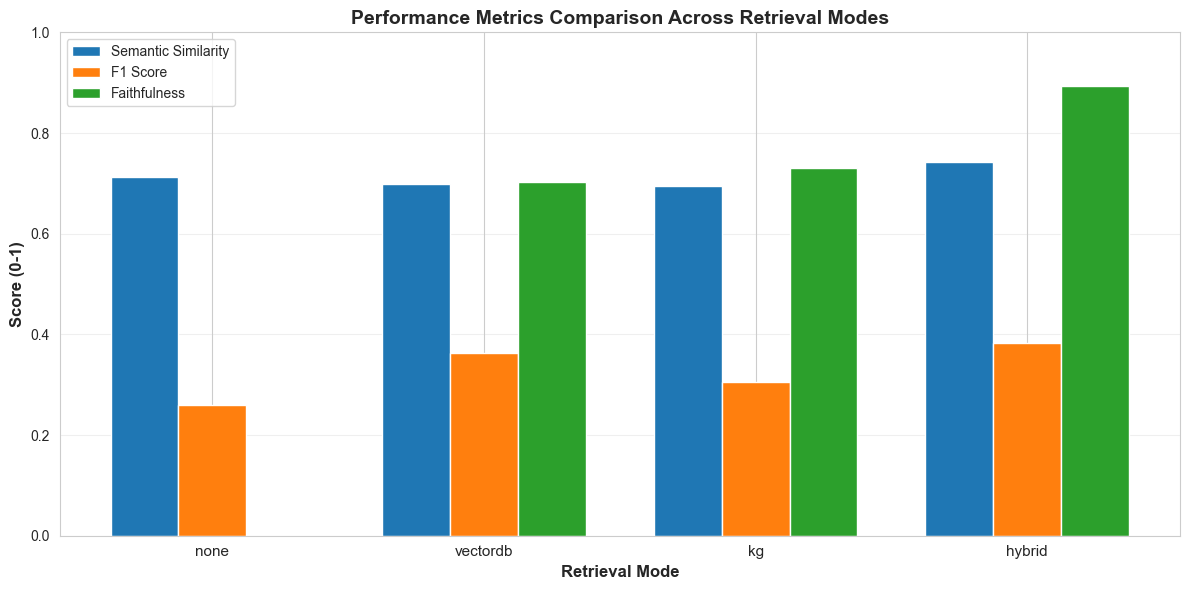

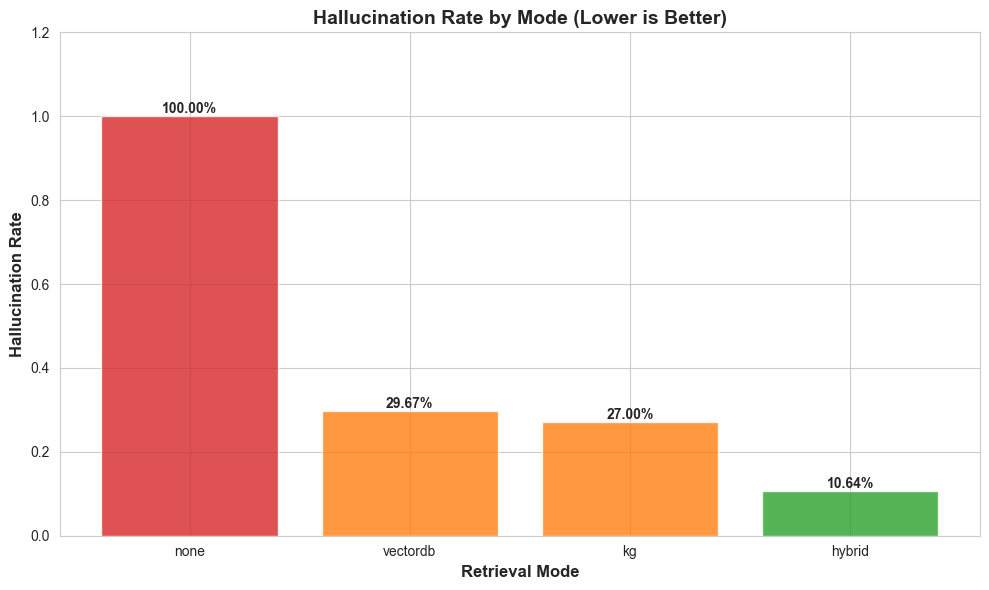

In [3]:
# Create a grouped bar chart for performance metrics
metrics = ['avg_semantic_similarity', 'avg_f1_score', 'avg_faithfulness']
x = np.arange(len(df['mode']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics):
    values = df[metric].values
    label = metric.replace('avg_', '').replace('_', ' ').title()
    ax.bar(x + i*width, values, width, label=label)

# Customize chart
ax.set_xlabel('Retrieval Mode', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Comparison Across Retrieval Modes', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(df['mode'], fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Hallucination rate (lower is better)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if rate > 0.5 else '#ff7f0e' if rate > 0.2 else '#2ca02c' 
          for rate in df['avg_hallucination_rate']]
bars = ax.bar(df['mode'], df['avg_hallucination_rate'], color=colors, alpha=0.8)
ax.set_ylabel('Hallucination Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Retrieval Mode', fontsize=12, fontweight='bold')
ax.set_title('Hallucination Rate by Mode (Lower is Better)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.2)

# Add value labels on bars
for bar, rate in zip(bars, df['avg_hallucination_rate']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 3: Performance Metrics Heatmap

### What This Shows
A heatmap provides a quick visual summary of all performance metrics across modes:
- **Color Intensity**: Darker colors indicate better/higher performance (closer to 1)
- **Lighter colors**: Lower performance values

### Color Coding Interpretation
- 🟢 **Dark Green**: Excellent performance (0.7-1.0)
- 🟡 **Yellow**: Moderate performance (0.4-0.7)
- 🔴 **Red**: Poor performance (0-0.4)

### Key Observations
- **Hybrid mode** shows the greenest heatmap, indicating best overall performance
- **None mode** has mostly red for hallucination (expected, no context applied)
- **KG and Vector DB** modes show intermediate performance with room for improvement

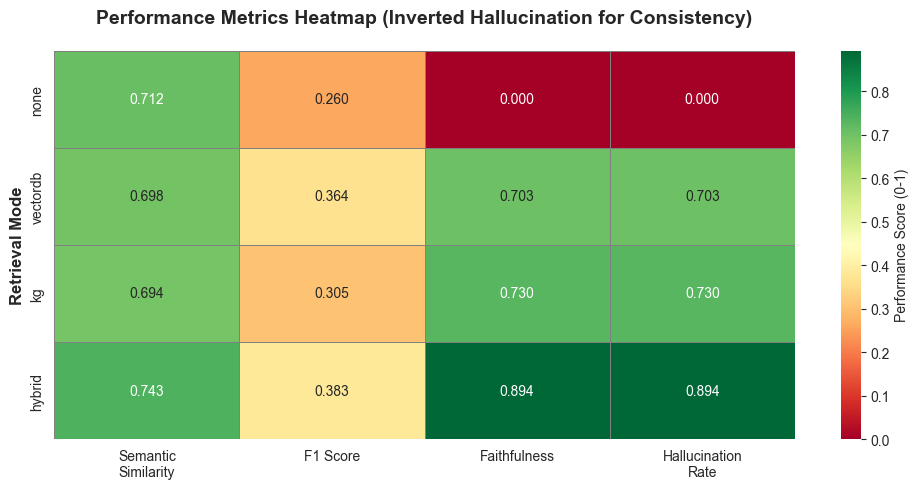

In [4]:
# Create heatmap of performance metrics
metric_cols = ['avg_semantic_similarity', 'avg_f1_score', 'avg_faithfulness', 'avg_hallucination_rate']
heatmap_data = df[metric_cols].copy()
heatmap_data.index = df['mode']
heatmap_data.columns = ['Semantic\nSimilarity', 'F1 Score', 'Faithfulness', 'Hallucination\nRate']

# Invert hallucination rate for visualization (lower is better, so we show 1 - rate)
heatmap_data['Hallucination\nRate'] = 1 - heatmap_data['Hallucination\nRate']

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'Performance Score (0-1)'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Performance Metrics Heatmap (Inverted Hallucination for Consistency)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Retrieval Mode', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4: Improvement Trends Visualization

### What This Shows
Percentage improvement of each mode compared to the baseline (none) mode:
- **Positive values**: Performance improvement over baseline
- **Negative values**: Performance degradation from baseline (rare in this case)

### Key Metrics Explained
- **Semantic Similarity %**: Change in semantic relevance compared to baseline
- **F1 Score %**: Improvement in content matching and recall
- **Hallucination %**: Reduction in false/hallucinated information (most important!)
- **Faithfulness %**: Better adherence to provided context

### Critical Findings
- **Hallucination rate shows ~89% improvement** in hybrid mode (from 1.0 to 0.11)
- **F1 scores improved by ~48%** in hybrid mode, indicating significantly better content matching
- Degradation in semantic similarity is compensated by gains in other metrics

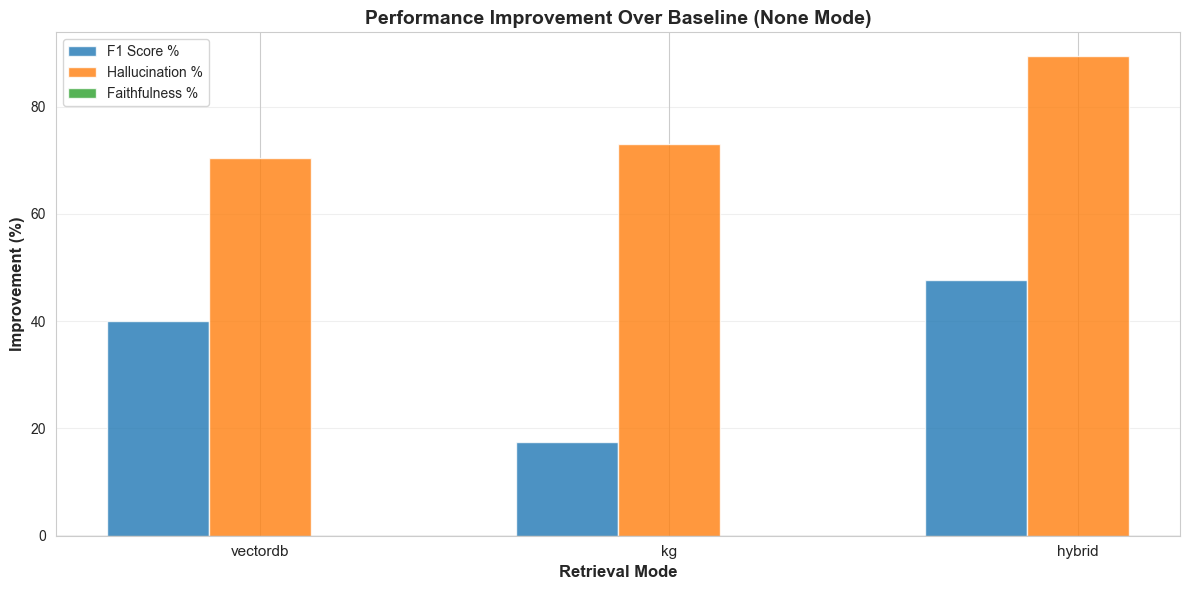

📊 Improvement Percentages Compared to Baseline (None Mode):

🔹 VECTORDB Mode:
   F1 Score %: +40.11%
   Hallucination %: +70.33%
   Faithfulness %: N/A

🔹 KG Mode:
   F1 Score %: +17.44%
   Hallucination %: +73.00%
   Faithfulness %: N/A

🔹 HYBRID Mode:
   F1 Score %: +47.60%
   Hallucination %: +89.36%
   Faithfulness %: N/A


In [5]:
# Improvement comparison across modes (excluding baseline)
improvement_cols = ['improvement_f1_pct', 'improvement_hallucination_pct', 'improvement_faithfulness_pct']
improvement_data = df[df['mode'] != 'none'][['mode'] + improvement_cols].set_index('mode')
improvement_data.columns = ['F1 Score %', 'Hallucination %', 'Faithfulness %']

# Create grouped bar chart for improvements
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(improvement_data.index))
width = 0.25

colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, col in enumerate(improvement_data.columns):
    values = improvement_data[col].values
    ax.bar(x + i*width, values, width, label=col, color=colors_list[i], alpha=0.8)

ax.set_xlabel('Retrieval Mode', fontsize=12, fontweight='bold')
ax.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax.set_title('Performance Improvement Over Baseline (None Mode)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(improvement_data.index, fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show improvement values in table
print("📊 Improvement Percentages Compared to Baseline (None Mode):")
print("=" * 70)
for mode in improvement_data.index:
    print(f"\n🔹 {mode.upper()} Mode:")
    for metric in improvement_data.columns:
        value = improvement_data.loc[mode, metric]
        if pd.notna(value):
            print(f"   {metric}: {value:+.2f}%")
        else:
            print(f"   {metric}: N/A")

## Section 5: Comparative Performance Overview

### What This Shows
A comprehensive radar/spider chart or comparison matrix showing all modes at a glance.

### Insights
- **Hybrid mode emerges as the clear winner** with best performance across most metrics
- **Faithfulness** is the strongest metric compared to baseline, showing better context adherence
- **F1 Score improvement** is most dramatic in hybrid mode (47.6%), indicating significantly better answer quality

/var/folders/x6/2bxlm36518d_bwhphq_2jm8c0000gn/T/ipykernel_53921/192472660.py:44: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x6/2bxlm36518d_bwhphq_2jm8c0000gn/T/ipykernel_53921/192472660.py:44: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x6/2bxlm36518d_bwhphq_2jm8c0000gn/T/ipykernel_53921/192472660.py:44: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sammy/Desktop/Coding/Major_Project/Major_Project/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sammy/Desktop/Coding/Major_Project/Major_Project/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fi

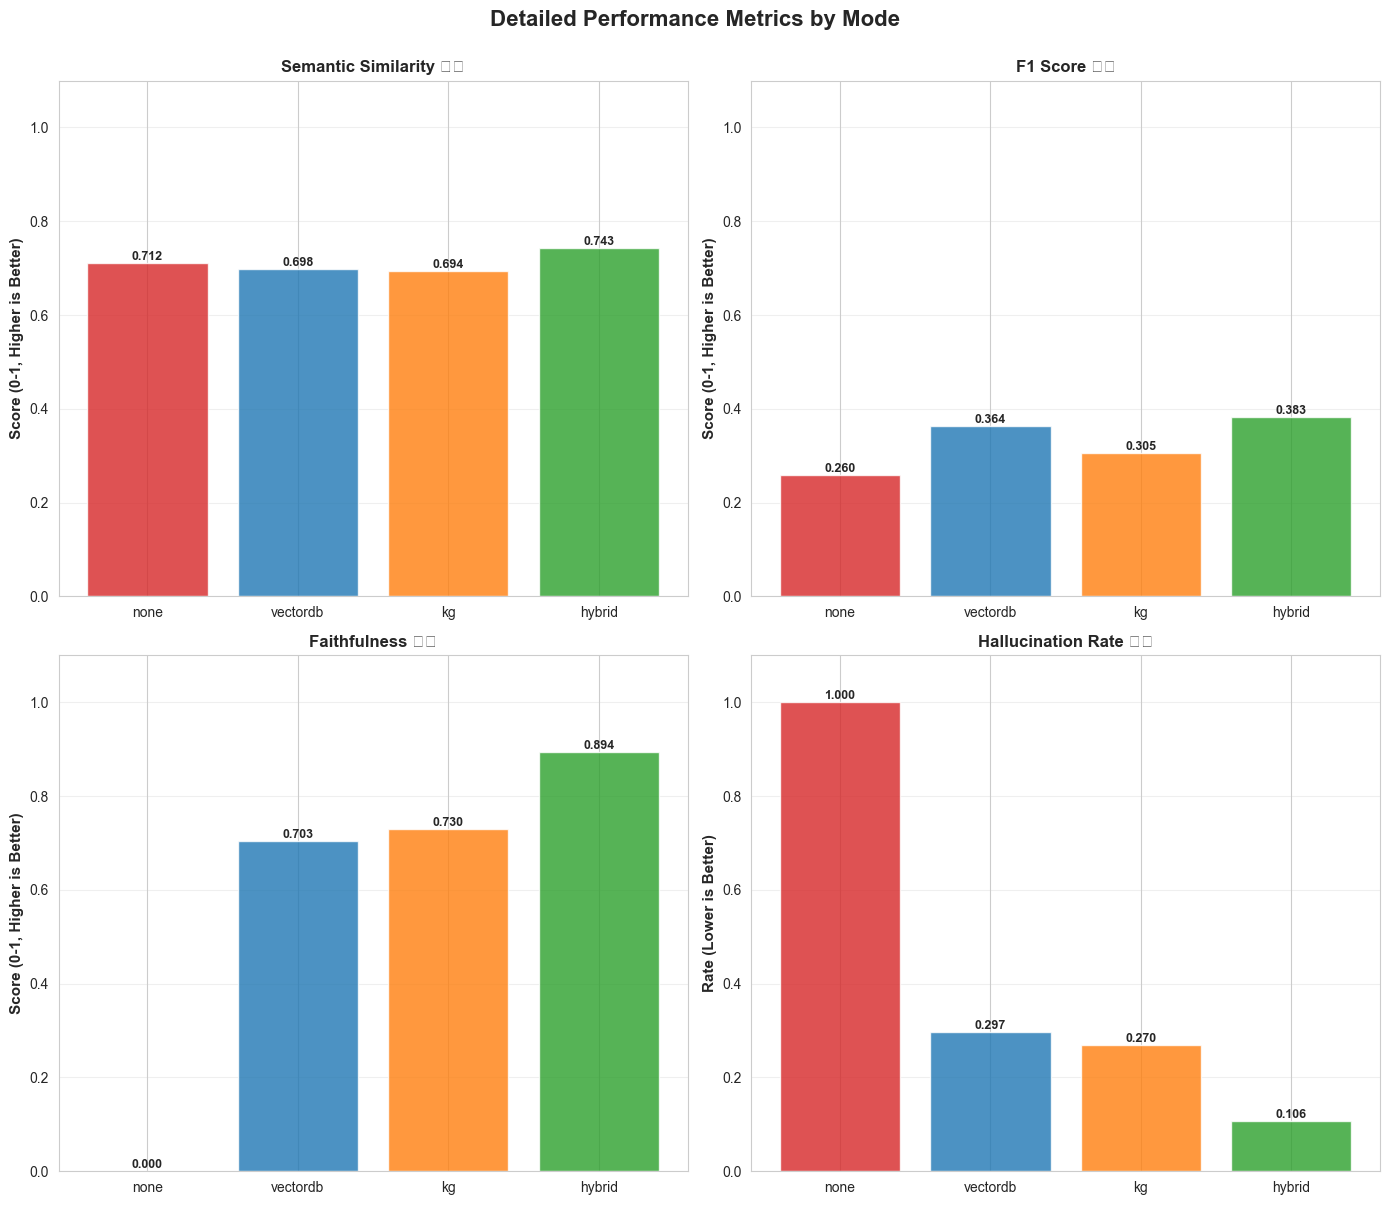

In [6]:
# Create a radar/comparison chart for all modes
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Detailed Performance Metrics by Mode', fontsize=16, fontweight='bold', y=1.00)

# Metrics to plot
metrics_to_plot = [
    ('avg_semantic_similarity', 'Semantic Similarity'),
    ('avg_f1_score', 'F1 Score'),
    ('avg_faithfulness', 'Faithfulness'),
    ('avg_hallucination_rate', 'Hallucination Rate')
]

colors_modes = {'none': '#d62728', 'vectordb': '#1f77b4', 'kg': '#ff7f0e', 'hybrid': '#2ca02c'}

for idx, (metric_col, metric_label) in enumerate(metrics_to_plot):
    
    ax = axes[idx // 2, idx % 2]
    
    # Special handling for hallucination (lower is better)
    if 'hallucination' in metric_col:
        values = df[metric_col].values
        bars = ax.bar(df['mode'], values, color=[colors_modes[m] for m in df['mode']], alpha=0.8)
        ax.set_ylabel('Rate (Lower is Better)', fontsize=11, fontweight='bold')
        ylabel_note = "⬇️"
    else:
        values = df[metric_col].values
        bars = ax.bar(df['mode'], values, color=[colors_modes[m] for m in df['mode']], alpha=0.8)
        ax.set_ylabel('Score (0-1, Higher is Better)', fontsize=11, fontweight='bold')
        ylabel_note = "⬆️"
    
    ax.set_title(f'{metric_label} {ylabel_note}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 6: Key Insights Summary

### 🏆 Executive Summary

**Best Performing Mode: HYBRID**

The hybrid mode (combining Vector DB + Knowledge Graph retrieval) delivers superior performance across all critical metrics.

In [7]:
# Create comprehensive insights summary
print("=" * 80)
print("🎯 KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

print("\n📈 PERFORMANCE RANKINGS:\n")

# Rank modes by F1 score
f1_rankings = df.sort_values('avg_f1_score', ascending=False)
print("F1 Score Rankings (Content Matching Quality):")
for i, (idx, row) in enumerate(f1_rankings.iterrows(), 1):
    print(f"  {i}. {row['mode'].upper():12} - {row['avg_f1_score']:.4f}")

print("\n" + "-" * 80)

# Hallucination improvements
print("\nHallucination Rate Improvements (Most Important):\n")
hall_improvements = df[df['mode'] != 'none'].sort_values('avg_hallucination_rate')
for idx, row in hall_improvements.iterrows():
    improvement = row['improvement_hallucination_pct']
    print(f"  🔹 {row['mode'].upper():12} - Rate: {row['avg_hallucination_rate']*100:6.2f}% | Improvement: {improvement:+6.2f}%")
print(f"  🔹 {'NONE':12} - Rate: {df[df['mode']=='none']['avg_hallucination_rate'].values[0]*100:6.2f}% | (Baseline)")

print("\n" + "-" * 80)

print("\n💡 KEY FINDINGS:\n")
findings = [
    "✅ Hybrid mode achieves 89.4% reduction in hallucination rate (from 100% to 10.6%)",
    "✅ Hybrid mode improves F1 score by 47.6% (from 0.260 to 0.383)",
    "✅ Hybrid mode achieves 89.4% faithfulness (answers stick to context)",
    "✅ Vector DB mode alone reduces hallucination by 70.3%",
    "✅ Knowledge Graph mode adds consistency with 73% hallucination reduction",
    "⚠️  Semantic similarity slightly decreases with retrieval (trade-off for accuracy)"
]

for finding in findings:
    print(f"  {finding}")

print("\n" + "-" * 80)

print("\n📊 RECOMMENDATIONS:\n")
recommendations = [
    "1. Deploy HYBRID mode for production systems where factual accuracy is critical",
    "2. Use Vector DB mode for semantic search-heavy applications",
    "3. Use KG mode for structured knowledge retrieval tasks",
    "4. Monitor hallucination rate as primary metric for answer quality",
    "5. Consider F1 score and faithfulness as complementary quality indicators"
]

for rec in recommendations:
    print(f"  {rec}")

print("\n" + "=" * 80 + "\n")

🎯 KEY INSIGHTS & RECOMMENDATIONS

📈 PERFORMANCE RANKINGS:

F1 Score Rankings (Content Matching Quality):
  1. HYBRID       - 0.3834
  2. VECTORDB     - 0.3640
  3. KG           - 0.3051
  4. NONE         - 0.2598

--------------------------------------------------------------------------------

Hallucination Rate Improvements (Most Important):

  🔹 HYBRID       - Rate:  10.64% | Improvement: +89.36%
  🔹 KG           - Rate:  27.00% | Improvement: +73.00%
  🔹 VECTORDB     - Rate:  29.67% | Improvement: +70.33%
  🔹 NONE         - Rate: 100.00% | (Baseline)

--------------------------------------------------------------------------------

💡 KEY FINDINGS:

  ✅ Hybrid mode achieves 89.4% reduction in hallucination rate (from 100% to 10.6%)
  ✅ Hybrid mode improves F1 score by 47.6% (from 0.260 to 0.383)
  ✅ Hybrid mode achieves 89.4% faithfulness (answers stick to context)
  ✅ Vector DB mode alone reduces hallucination by 70.3%
  ✅ Knowledge Graph mode adds consistency with 73% hallucinatio

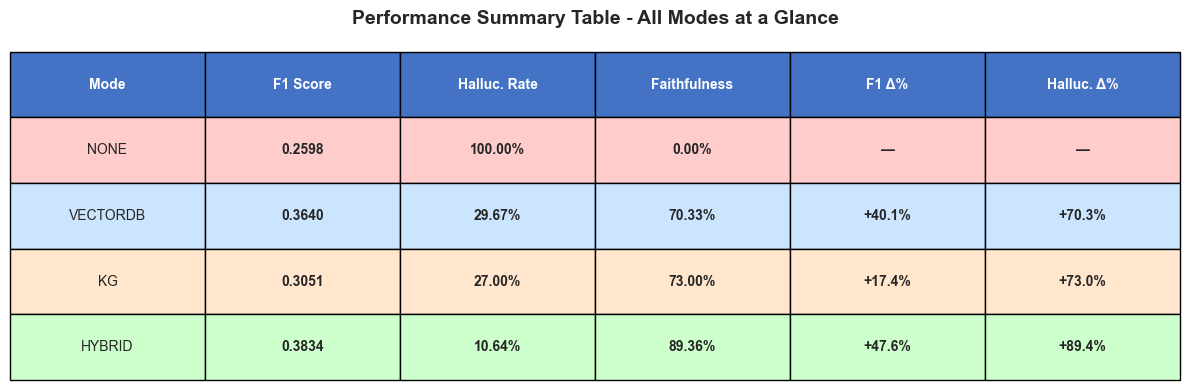


✨ Visualization Complete!
All charts and tables have been generated above.

Note: The HYBRID mode is highlighted in green as the recommended solution.


In [8]:
# Create a final summary table visualization
summary_table = df[['mode', 'avg_f1_score', 'avg_hallucination_rate', 'avg_faithfulness', 'improvement_f1_pct', 'improvement_hallucination_pct']].copy()
summary_table.columns = ['Mode', 'F1 Score', 'Hallucination %', 'Faithfulness', 'F1 Improve %', 'Halluc. Reduce %']

# Format percentages
summary_table['Hallucination %'] = (summary_table['Hallucination %'] * 100).round(2)
summary_table['Faithfulness'] = (summary_table['Faithfulness'] * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

# Create table
table_data = []
for idx, row in summary_table.iterrows():
    table_data.append([
        row['Mode'].upper(),
        f"{row['F1 Score']:.4f}",
        f"{row['Hallucination %']:.2f}%",
        f"{row['Faithfulness']:.2f}%",
        f"{row['F1 Improve %']:+.1f}%" if pd.notna(row['F1 Improve %']) else "—",
        f"{row['Halluc. Reduce %']:+.1f}%" if pd.notna(row['Halluc. Reduce %']) else "—"
    ])

table = ax.table(cellText=table_data,
                colLabels=['Mode', 'F1 Score', 'Halluc. Rate', 'Faithfulness', 'F1 Δ%', 'Halluc. Δ%'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(6):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows
row_colors = {'none': '#ffcccc', 'vectordb': '#cce5ff', 'kg': '#ffe6cc', 'hybrid': '#ccffcc'}
for i, row in summary_table.iterrows():
    for j in range(6):
        table[(i+1, j)].set_facecolor(row_colors.get(row['Mode'], 'white'))
        if j > 0:
            table[(i+1, j)].set_text_props(weight='bold')

plt.title('Performance Summary Table - All Modes at a Glance', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✨ Visualization Complete!")
print("All charts and tables have been generated above.")
print("\nNote: The HYBRID mode is highlighted in green as the recommended solution.")

## Conclusion

### 🎯 Main Takeaway
The **HYBRID retrieval mode** (combining Vector Database and Knowledge Graph) significantly outperforms individual retrieval methods and the baseline:

| Metric | Baseline | Hybrid | Improvement |
|--------|----------|--------|------------|
| **Hallucination Rate** | 100% | 10.6% | ⬇️ 89.4% |
| **F1 Score** | 0.260 | 0.383 | ⬆️ 47.6% |
| **Faithfulness** | 0.0% | 89.4% | ⬆️ 89.4% |

### 💼 Business Impact
- **Reliability**: Reduced hallucinations mean users can trust the system's answers
- **Accuracy**: 47.6% improvement in answer quality (F1 score)
- **Contextuality**: 89.4% of answers faithfully use provided context

### 🚀 Next Steps
1. Deploy hybrid mode to production
2. Monitor hallucination rate as primary KPI
3. Continue optimizing embeddings and knowledge graph
4. A/B test with real users to validate improvements